In [1]:
# ! pip install einops
# ! pip install open_clip_torch

In [1]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision.transforms.functional import pil_to_tensor

In [2]:
local_image_path = '/workspace/projects/Grounded-Segment-Anything/assets/inpaint_demo.jpg'

In [3]:
# ==========================================
# CONFIGURATION
# ==========================================
# Options: "c-radio_v3-b" or "c-radio_v4-so400m"
# MODEL_VERSION = "c-radio_v4-so400m"
MODEL_VERSION = "c-radio_v3-b"

# Options: "siglip2" or "clip" or "dino_v2" or "sam" (Note: "clip" is only supported on v3)
# ADAPTOR_NAME = "siglip2-g" # for c-radio-v4
ADAPTOR_NAME = "siglip2"
# ADAPTOR_NAME = "clip"

# NACLIP-style dense prediction settings (sharper spatial features -> cleaner heatmaps).
USE_NACLIP = True
NACLIP_STRATEGY = "kkonly"     # attention-only self-similarity, tends to give crisper maps
NACLIP_GAUSSIAN_STD = 5.0
FIXED_PATCH_DIM = (40, 40)     # set to None to use the model's default patch grid

device = "cuda" if torch.cuda.is_available() else "cpu"

/root/miniconda3/envs/radio_env/lib/python3.10/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [4]:
# ==========================================
# 1. LOAD MODEL & ADAPTOR VIA TORCHHUB
# ==========================================
print(f"Loading {MODEL_VERSION} with {ADAPTOR_NAME} adaptor...")
model = torch.hub.load(
    "NVlabs/RADIO",
    "radio_model",
    version=MODEL_VERSION,
    adaptor_names=[ADAPTOR_NAME],
    progress=True,
    skip_validation=True,
    use_naclip=USE_NACLIP,
    naclip_strategy=NACLIP_STRATEGY,
    naclip_gaussian_std=NACLIP_GAUSSIAN_STD,
    fixed_patch_dim=FIXED_PATCH_DIM,
    gaussian_device=device,
    use_summary_for_spatial=True,
).to(device).eval()

# Retrieve the specific vision-language adaptor from the model
adaptor = model.adaptors[ADAPTOR_NAME]

Loading c-radio_v3-b with siglip2 adaptor...


Using cache found in /root/.cache/torch/hub/NVlabs_RADIO_main
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

In [16]:
IMAGE_PATH = local_image_path
# TEXT_PROMPTS = ["a fluffy dog"]#, "bench"]
TEXT_PROMPTS = ["a bench"]

In [17]:
# ==========================================
# 2. PREPROCESS & RUN IMAGE FORWARD PASS
# ==========================================
raw_image = Image.open(IMAGE_PATH).convert("RGB")

# RADIO uses torchvision's pil_to_tensor scaled to [0, 1]
img_tensor = pil_to_tensor(raw_image).unsqueeze(0).to(device, dtype=torch.float32) / 255.0

# Resize to the nearest resolution RADIO actually supports, rather than the raw image size.
nearest_res = model.get_nearest_supported_resolution(*img_tensor.shape[-2:])
img_tensor = F.interpolate(img_tensor, nearest_res, mode="bilinear", align_corners=False)
print(f"Nearest supported resolution: {nearest_res}")

with torch.no_grad():
    # Model forward pass automatically runs loaded adaptors internally.
    # feature_fmt='NCHW' avoids having to guess the patch grid shape ourselves.
    outputs = model(img_tensor, feature_fmt="NCHW")
 
    # Extract adaptor features (returns RadioOutput tuple: summary token, spatial features)
    summary_token, spatial_features = outputs[ADAPTOR_NAME]
    assert spatial_features.ndim == 4  # (B, C, H, W)
 
print("Spatial Features Shape:", spatial_features.shape)

Nearest supported resolution: Resolution(height=512, width=512)
Spatial Features Shape: torch.Size([1, 1152, 32, 32])


In [18]:
# ==========================================
# 3. ENCODE TEXT PROMPTS
# ==========================================
with torch.no_grad():
    # Tokenize and encode text using adaptor-specific text head
    tokens = adaptor.tokenizer(TEXT_PROMPTS).to(device)
    text_features = adaptor.encode_text(tokens, normalize=True)

print("Text Features Shape:", text_features.shape)

Text Features Shape: torch.Size([1, 1152])


In [19]:
# ==========================================
# 4. COMPUTE SIMILARITY MAPS & DISPLAY HEATMAP
# ==========================================
# L2 Normalize along feature dimensions for Cosine Similarity
spatial_features_n = F.normalize(spatial_features, p=2, dim=1)  # (1, C, H, W)
text_features_n = F.normalize(text_features, p=2, dim=-1)       # (N_prompts, C)
 
# Compute similarity matrix across matching projection dimensions
similarity_maps = torch.einsum("bchw,nc->bnhw", spatial_features_n, text_features_n)  # (1, N, h, w)
print("Similarity maps shape:", similarity_maps.shape)

Similarity maps shape: torch.Size([1, 1, 32, 32])


## Simple Patch Heatmap

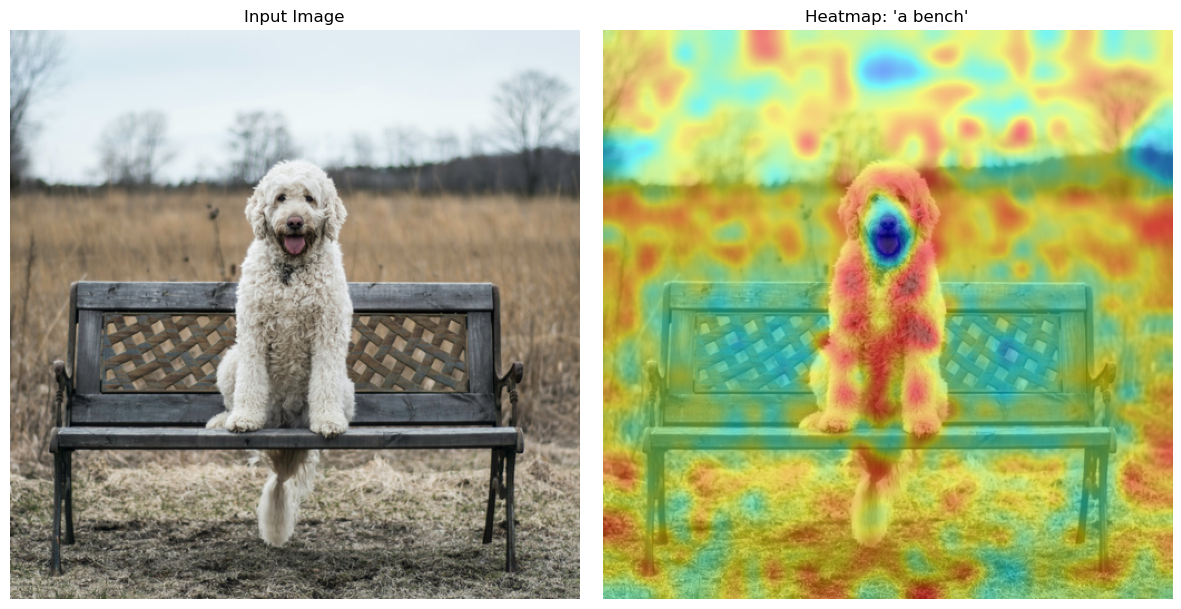

In [20]:
## Simple patch predictions

# Extract map for first prompt
prompt_idx = 0
sim_map = similarity_maps[0, prompt_idx].cpu().numpy()

# Resize heatmap to match original image size
orig_w, orig_h = raw_image.size
sim_map_resized = cv2.resize(sim_map, (orig_w, orig_h), interpolation=cv2.INTER_CUBIC)

# Min-Max normalize for display
sim_map_norm = (sim_map_resized - sim_map_resized.min()) / (
    sim_map_resized.max() - sim_map_resized.min() + 1e-8
)

# Render overlay using JET colormap
heatmap = cv2.applyColorMap(np.uint8(255 * sim_map_norm), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
overlay = np.uint8(np.clip(np.float32(heatmap) * 0.5 + np.float32(raw_image) * 0.5, 0, 255))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(raw_image)
axes[0].set_title("Input Image")
axes[0].axis("off")

axes[1].imshow(overlay)
axes[1].set_title(f"Heatmap: '{TEXT_PROMPTS[prompt_idx]}'")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## PAMR Refined Masks

In [ ]:
import sys
repo_root = "/workspace/projects/nvidia_radio"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
if "radio" in sys.modules:
    del sys.modules["radio"]
from radio.pamr import PAMR

In [ ]:
# ==========================================
# 5. REFINE WITH PAMR (Pixel-Adaptive Mask Refinement)
# ==========================================
import sys
repo_root = "/workspace/projects/nvidia_radio"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
if "radio" in sys.modules:
    del sys.modules["radio"]
from radio.pamr import PAMR
 
# Upsample the coarse patch-level similarity map to the model's input resolution first,
# then let PAMR refine it using the (unnormalized, 0-255) image as guidance.
sim_upsampled = F.interpolate(
    similarity_maps, size=img_tensor.shape[-2:], mode="bilinear", align_corners=False
)  # (1, N, H, W)
 
pamr = PAMR(10, dilations=[1, 2]).to(device)
sim_refined = pamr(img_tensor * 255, sim_upsampled)  # (1, N, H, W)
sim_refined = sim_refined.squeeze(0).detach().cpu().numpy()  # (N, H, W)

print("Refined similarity maps shape:", sim_refined.shape)

In [ ]:
# ## Visualize
#
# Two views, mirroring the built-in text-head script:
#
# 1. A hard segmentation map (argmax over prompts, per pixel) shown side-by-side with the
#    original image.
# 2. Per-prompt soft heatmaps overlaid on the original image, using the PAMR-refined
#    similarity.
 
# ==========================================
# 6a. HARD SEGMENTATION MAP (argmax across prompts)
# ==========================================
num_queries = len(TEXT_PROMPTS)
pred_labels = sim_refined.argmax(axis=0)  # (H, W)
 
cmap = plt.get_cmap("tab10", num_queries)
color_map = np.array([cmap(i)[:3] for i in range(num_queries)])  # (Q, 3)
 
segmap = np.zeros((*pred_labels.shape, 3), dtype=np.float32)
for q in range(num_queries):
    segmap[pred_labels == q] = color_map[q]
 
img_resized = raw_image.resize(
    (img_tensor.shape[-1], img_tensor.shape[-2]), Image.Resampling.LANCZOS
)
img_rgb = np.array(img_resized) / 255.0
 
viz_img = np.concatenate([img_rgb, np.clip(segmap, 0, 1)], axis=1)
 
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[20, 1], hspace=0.1)
 
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("Patch-Level Text Alignment (PAMR-refined)")
ax1.imshow(viz_img)
ax1.axis("off")
 
ax_legend = fig.add_subplot(gs[1, 0])
ax_legend.axis("off")
handles = [plt.Line2D([0], [0], color=color_map[i], lw=6) for i in range(num_queries)]
ax_legend.legend(handles, TEXT_PROMPTS, loc="center", ncol=num_queries, fontsize="small", frameon=False)
 
plt.show()

In [ ]:
# ==========================================
# 6b. PER-PROMPT SOFT HEATMAPS
# ==========================================
orig_w, orig_h = raw_image.size
 
fig, axes = plt.subplots(1, num_queries, figsize=(5 * num_queries, 5), squeeze=False)
 
for i, prompt in enumerate(TEXT_PROMPTS):
    heatmap = cv2.resize(sim_refined[i], (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
 
    ax = axes[0, i]
    ax.imshow(raw_image)
    im = ax.imshow(heatmap, cmap="jet", alpha=0.45)
    ax.set_title(f"Query: '{prompt}'", fontsize=12, fontweight="bold")
    ax.axis("off")
    fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.04, fraction=0.046)
 
plt.tight_layout()
plt.show()